<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Analyzing_Patient_Vital_Signs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing Patient Vital Signs with Descriptive Statistic**

## **Overview**
Descriptive statistic for patient vital signs are essential for clinical monitoring, triage, and research. This project demonstrate how to clean, prepare, analyze, visualize, summarize and report vital-sign data.

##**Objectives**
- Load and inspect a paitent vital sighs dataset
- Clean and prepare dataset for analysis
- Compute and interpret descriptive statistics
- Data visualization
- Summary and Report

## **The dataset**
The simulated dataset representing repeated vital sign measurements for hospitalized patients collected across several wards over multiple days. These are the columns:
- patient_id - unique patient identifier
- age - patient age in year
- sex - 'M' or 'F'
- ward - ward name (e.g. Med, Surg, ICU)
- timestamp - datetime of measurement
- hr - heart rate (beats per minute)
- sbp - systolic blood pressure
- dbp - diastolic blood pressure
- spo2- oxygen saturation (%)
- temp_c - temperature in celsius
- resp_rate - respiratory rate (breath per minute)

## STEP 0: Setup
Import Libraries

In [16]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

# (optional)Reproducibility - make the notebook predictable
RNG = np.random.default_rng(42)
random.seed(42)

pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
print('Setup complete.')

Setup complete.


Create Dataset

The following cell simulates a realistic, clinically plausible patient vital-signs dataset by generating demographic attributes, assigning patients to wards, creating timestamped vital-sign measurements over multiple days, and adding natural variability, missing values, and occasional outliers to mirror real-world hospital data for analysis and practice.

In [17]:
# Function to simulate vital signs dataset
def simulate_vitals(n_patients=120, days=4, measurements_per_day=3, start_date=datetime(2025,11,20,6,0)):
    patient_ids = [f"P{1000+i}" for i in range(n_patients)]
    records = []
    wards = ['Med', 'Surg', 'ICU']
    for pid in patient_ids:
        age = int(RNG.normal(58, 16)) if RNG.random() > 0.05 else int(RNG.normal(35, 8))
        sex = 'M' if RNG.random() < 0.53 else 'F'
        ward = RNG.choice(wards, p=[0.55, 0.35, 0.10])
        baseline_hr = int(max(40, RNG.normal(78, 12)))
        baseline_sbp = int(max(80, RNG.normal(125, 14)))
        baseline_dbp = int(max(40, RNG.normal(78, 9)))
        baseline_spo2 = int(min(100, max(85, RNG.normal(97, 2))))
        baseline_temp = round(RNG.normal(36.7, 0.4), 1)
        for d in range(days):
            for m in range(measurements_per_day):
                ts = start_date + timedelta(days=d, hours=m*6) + timedelta(minutes=int(RNG.normal(0,30)))
                hr = int(np.clip(RNG.normal(baseline_hr, 8), 30, 200))
                sbp = int(np.clip(RNG.normal(baseline_sbp, 10), 60, 260))
                dbp = int(np.clip(RNG.normal(baseline_dbp, 6), 30, 160))
                spo2 = int(np.clip(RNG.normal(baseline_spo2, 1.8), 70, 100))
                temp_c = round(np.clip(RNG.normal(baseline_temp, 0.25), 34.0, 41.0), 1)
                resp_rate = int(np.clip(RNG.normal(16, 3), 6, 40))
                # inject missingness
                if RNG.random() < 0.05:
                    hr = np.nan
                if RNG.random() < 0.04:
                    sbp = np.nan
                    dbp = np.nan
                if RNG.random() < 0.03:
                    spo2 = np.nan
                # inject rare outliers
                if RNG.random() < 0.01:
                    hr = int(RNG.normal(160, 8))
                if RNG.random() < 0.005:
                    temp_c = round(RNG.normal(40.2, 0.6), 1)
                records.append({
                    'patient_id': pid,
                    'age': age,
                    'sex': sex,
                    'ward': ward,
                    'timestamp': ts,
                    'hr': hr,
                    'sbp': sbp,
                    'dbp': dbp,
                    'spo2': spo2,
                    'temp_c': temp_c,
                    'resp_rate': resp_rate
                })
    df = pd.DataFrame.from_records(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

# Create dataset
df = simulate_vitals(n_patients=120, days=4, measurements_per_day=3)
df.head()

,patient_id,age,sex,ward,timestamp,hr,sbp,dbp,spo2,temp_c,resp_rate
0,P1014,61,M,Med,2025-11-20 06:01:00,71.0,126.0,78.0,98.0,37.5,14
1,P1050,65,M,Med,2025-11-21 18:25:00,65.0,115.0,92.0,98.0,36.5,20
2,P1045,30,M,Med,2025-11-22 18:42:00,58.0,120.0,74.0,99.0,36.9,11
3,P1005,52,F,Med,2025-11-21 17:48:00,75.0,112.0,89.0,99.0,37.6,12
4,P1052,48,M,ICU,2025-11-21 12:52:00,68.0,115.0,75.0,96.0,36.8,13


### Step 1: Data Inspection

In [18]:
print('Rows, Columns:', df.shape, '\n')
print(df.dtypes)
df.describe(include='all').T

Rows, Columns: (1440, 11) 

patient_id            object
age                    int64
sex                   object
ward                  object
timestamp     datetime64[ns]
hr                   float64
sbp                  float64
dbp                  float64
spo2                 float64
temp_c               float64
resp_rate              int64
dtype: object


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,1440,120,P1014,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1440.0,NaN,NaN,NaN,56.125,17.0,44.5,55.5,67.0,99.0,17.31187
sex,1440,2,M,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ward,1440,3,Med,828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,1440,NaN,NaN,NaN,2025-11-21 23:59:29.916666624,2025-11-20 04:27:00,2025-11-21 02:16:00,2025-11-22 00:09:30,2025-11-22 21:50:15,2025-11-23 19:27:00,NaN
hr,1375.0,NaN,NaN,NaN,77.959273,37.0,68.0,77.0,87.0,173.0,16.149991
sbp,1385.0,NaN,NaN,NaN,123.279422,70.0,111.0,123.0,135.0,175.0,17.881653
dbp,1385.0,NaN,NaN,NaN,78.331408,40.0,71.0,78.0,86.0,109.0,10.718309
spo2,1395.0,NaN,NaN,NaN,95.976344,87.0,94.0,96.0,98.0,100.0,2.369131
temp_c,1440.0,NaN,NaN,NaN,36.732986,35.4,36.4,36.7,37.0,41.0,0.532478


### Step 2: Descriptive Statistic for continuas data (all vital-signs)

In [34]:
# Decriptive Stat of vital-signs -- check for Center tendencies and unusual data
vital_cols = ['hr', 'sbp', 'dbp', 'spo2', 'temp_c', 'resp_rate']

summary = df[vital_cols].describe().T

summary['median'] = summary['50%']
summary['IQR'] = summary['75%'] - summary['25%']

summary

,count,mean,std,min,25%,50%,75%,max,median,IQR
hr,1375.0,77.959273,16.149991,37.0,68.0,77.0,87.0,173.0,77.0,19.0
sbp,1385.0,123.279422,17.881653,70.0,111.0,123.0,135.0,175.0,123.0,24.0
dbp,1385.0,78.331408,10.718309,40.0,71.0,78.0,86.0,109.0,78.0,15.0
spo2,1395.0,95.976344,2.369131,87.0,94.0,96.0,98.0,100.0,96.0,4.0
temp_c,1440.0,36.732986,0.532478,35.4,36.4,36.7,37.0,41.0,36.7,0.6
resp_rate,1440.0,15.504861,2.963991,6.0,13.0,15.0,18.0,28.0,15.0,5.0


### Step 3: Visualize Distribution:


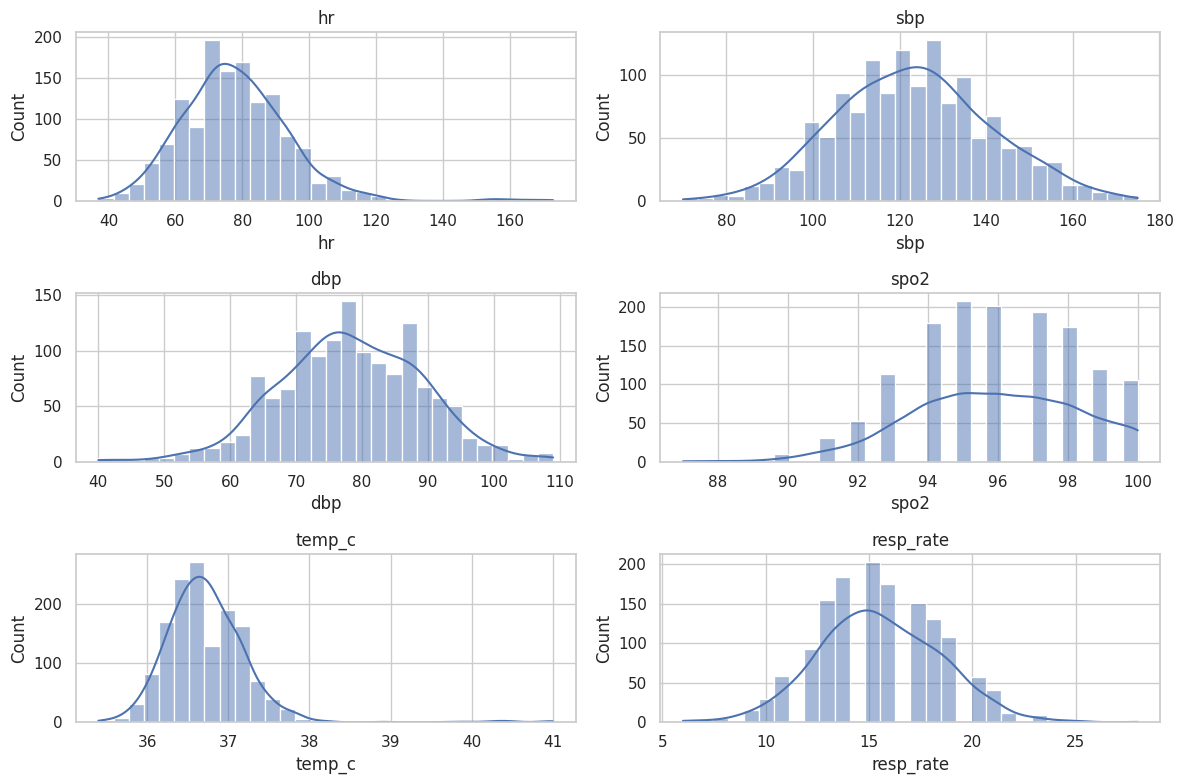

In [20]:
# Histograms - for quick identification of patterns, ranges, skewness, and potential outliers across the clinical measurements.
plt.figure(figsize=(12, 8))
for i, col in enumerate(vital_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col)
plt.tight_layout()

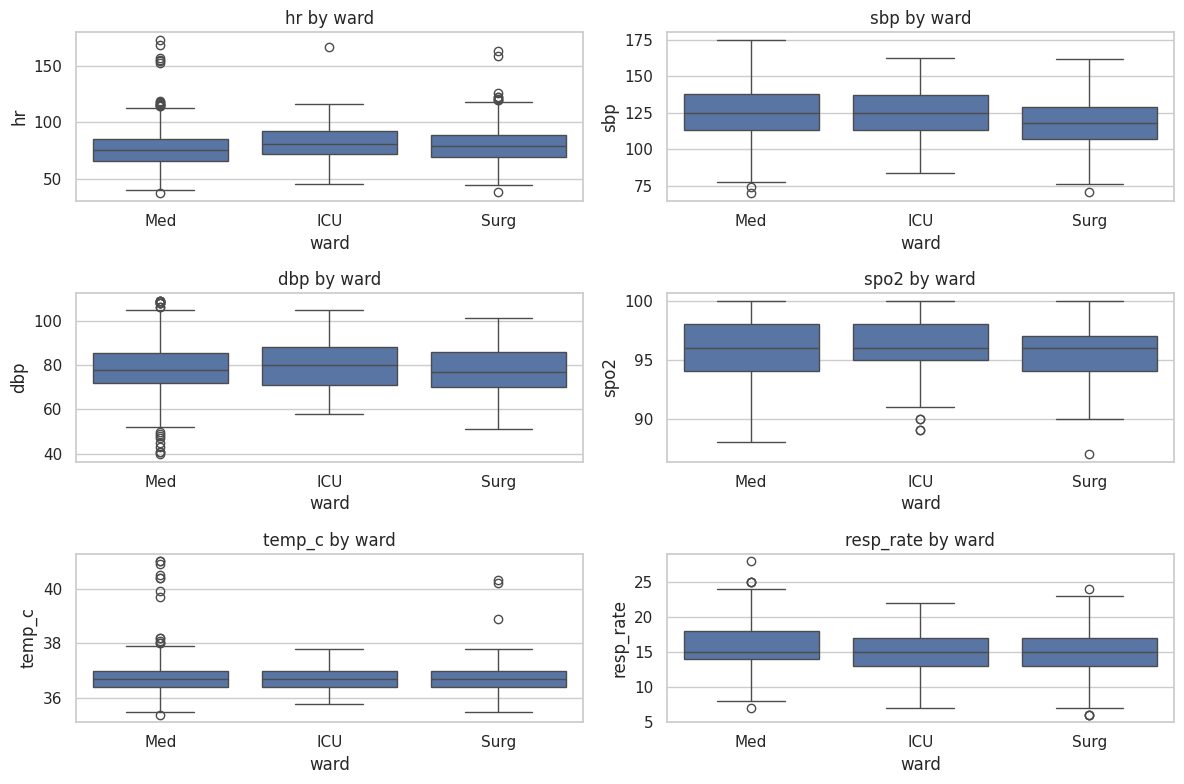

In [21]:
# Boxplots by ward - for quick identification of differences, variability, and potential outliers between patient groups
plt.figure(figsize=(12, 8))
for i, col in enumerate(['hr', 'sbp', 'dbp', 'spo2','temp_c', 'resp_rate']):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x='ward', y=col, data=df)
    plt.title(f'{col} by ward')
plt.tight_layout()

### Step 4: Missing Data

In [47]:
# Find missing values
Missing_value = df.isna().sum()
print("Missing Values:", Missing_value)

Missing Values: patient_id     0
age            0
sex            0
ward           0
timestamp      0
hr            65
sbp           55
dbp           55
spo2          45
temp_c         0
resp_rate      0
age_group      0
dtype: int64


120

In [22]:
# Percentage of missing values in each column
missing_pct = df.isna().mean().round(3) * 100
print('Missing % per column:\n', missing_pct)

Missing % per column:
 patient_id    0.0
age           0.0
sex           0.0
ward          0.0
timestamp     0.0
hr            4.5
sbp           3.8
dbp           3.8
spo2          3.1
temp_c        0.0
resp_rate     0.0
dtype: float64


In [23]:
# Handling missing values by sorting and then forward-fill and backward-fill
df_sorted = df.sort_values(['patient_id', 'timestamp']).copy()
df_ffill = df_sorted.groupby('patient_id').apply(lambda x: x.ffill().bfill(), include_groups=False).reset_index(drop=True)

# Compare missing-value counts before and after imputation
print('Before missing counts:\n', df.isna().sum())
print('After ffill/bfill counts:\n', df_ffill.isna().sum())

Before missing counts:
 patient_id     0
age            0
sex            0
ward           0
timestamp      0
hr            65
sbp           55
dbp           55
spo2          45
temp_c         0
resp_rate      0
dtype: int64
After ffill/bfill counts:
 age          0
sex          0
ward         0
timestamp    0
hr           0
sbp          0
dbp          0
spo2         0
temp_c       0
resp_rate    0
dtype: int64


###Step 5: Outlier Detection (using IQR)

In [24]:
# Interquartile range (IQR) method for detection of unusually high/low values that may need investigation or cleaning.
def iqr_outliers(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series[(series < lower) | (series > upper)]

# Detect of outlier for heart rate
hr_outliers = iqr_outliers(df['hr'].dropna())
print('HR outliers count:', len(hr_outliers))

HR outliers count: 25


### Step 6: Group summaries (by ward, gender, age)

In [25]:
# Group patients by ward, gender, and age, then compute median, and IQR
bins = [0, 30, 50, 65, 120]
labels = ['<30', '30-49', '50-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

agg = df.groupby(['ward', 'sex', 'age_group']).agg(
    hr_median=('hr', 'median'),
    hr_iqr=('hr', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    sbp_median=('sbp', 'median'),
    sbp_iqr=('sbp', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    count=('patient_id', 'count')
).reset_index()
agg.head(12)

/tmp/ipykernel_9927/1138034398.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['ward', 'sex', 'age_group']).agg(


,ward,sex,age_group,hr_median,hr_iqr,sbp_median,sbp_iqr,count
0,ICU,F,<30,NaN,NaN,NaN,NaN,0
1,ICU,F,30-49,77.5,21.25,138.5,13.75,24
2,ICU,F,50-64,75.0,11.00,146.0,17.50,24
3,ICU,F,65+,77.0,30.00,117.0,18.50,48
4,ICU,M,<30,96.0,10.50,112.0,26.50,12
5,ICU,M,30-49,75.0,10.00,123.0,17.25,24
6,ICU,M,50-64,89.5,6.50,130.0,18.00,24
7,ICU,M,65+,83.5,15.25,119.0,9.75,24
8,Med,F,<30,77.5,14.00,120.5,9.25,12
9,Med,F,30-49,70.5,16.25,132.5,23.25,60


### Step 7: Pateint-level summaries and variability

In [26]:
# Calculate key statistical metrics (e.g mean, SD, and max values) of individual pateint -- To understand variability of individual patient overtime.
patient_summary = df.groupby('patient_id').agg(
    n_measurements=('hr', 'count'),
    hr_mean=('hr', 'mean'),
    hr_std=('hr', 'std'),
    sbp_mean=('sbp', 'mean'),
    sbp_std=('sbp', 'std'),
    spo2_mean=('spo2', 'mean'),
    temp_max=('temp_c', 'max')
).reset_index()
patient_summary.head()

,patient_id,n_measurements,hr_mean,hr_std,sbp_mean,sbp_std,spo2_mean,temp_max
0,P1000,11,55.000000,5.603570,106.818182,7.277612,95.000000,36.9
1,P1001,12,79.833333,7.056053,148.083333,10.396313,96.750000,36.9
2,P1002,12,59.250000,9.274844,138.250000,7.085517,96.363636,36.5
3,P1003,11,100.818182,8.818369,129.000000,8.301150,97.200000,36.5
4,P1004,11,94.272727,25.791824,119.833333,10.052890,93.750000,36.7


### Step 8: Relationship and Correlations

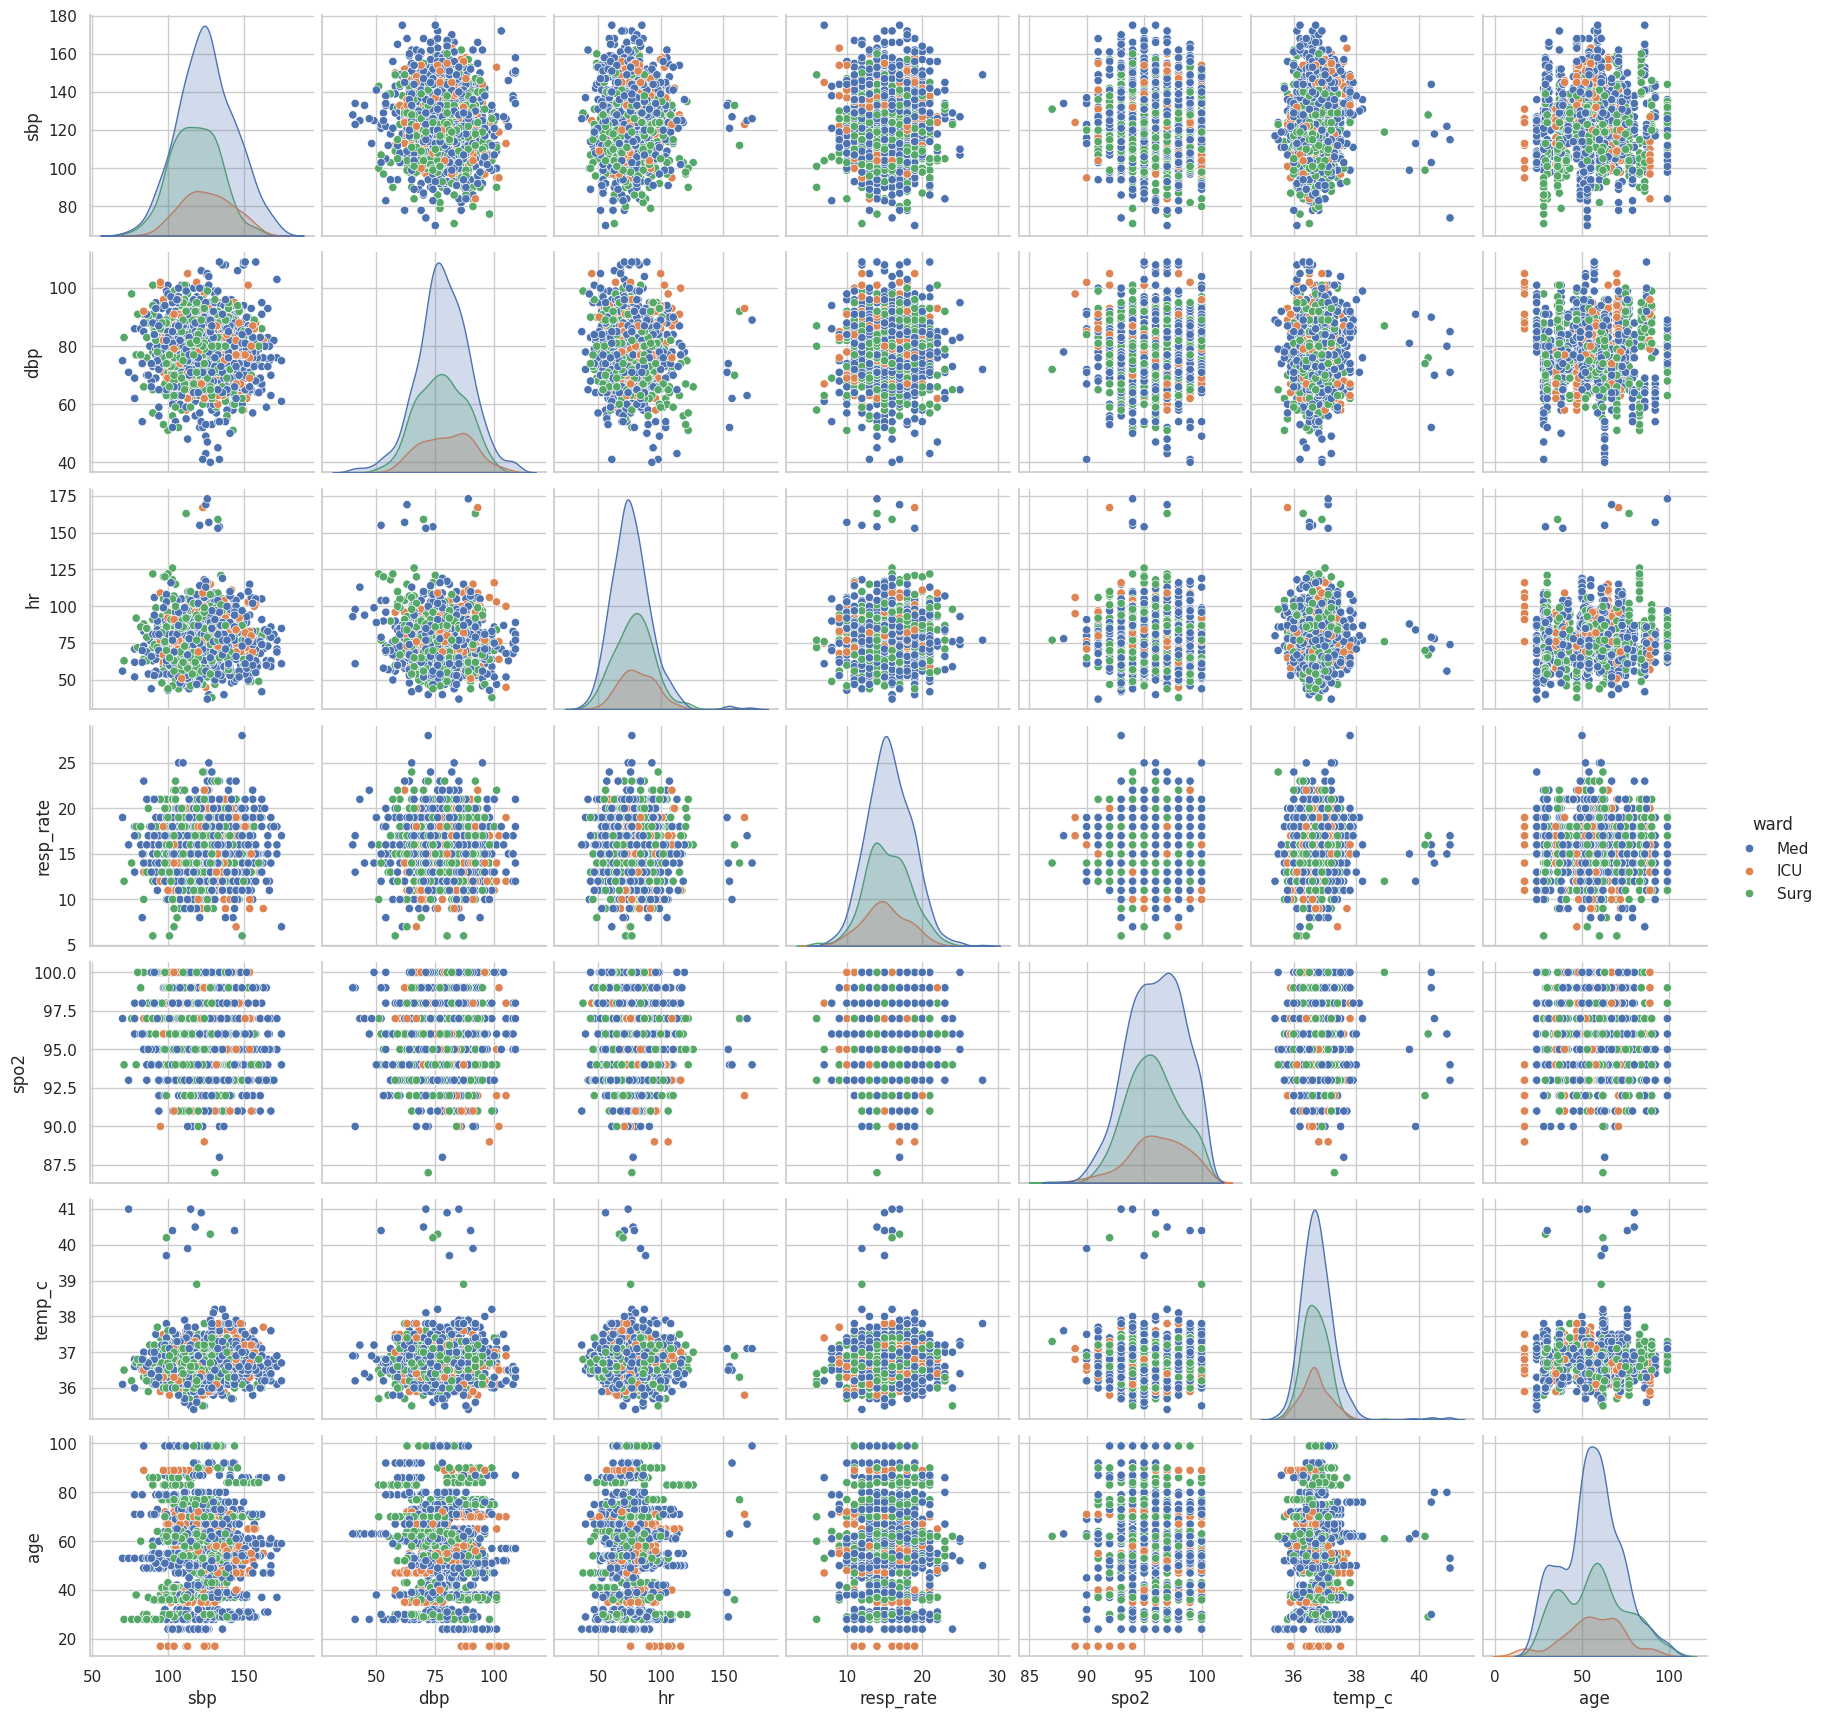

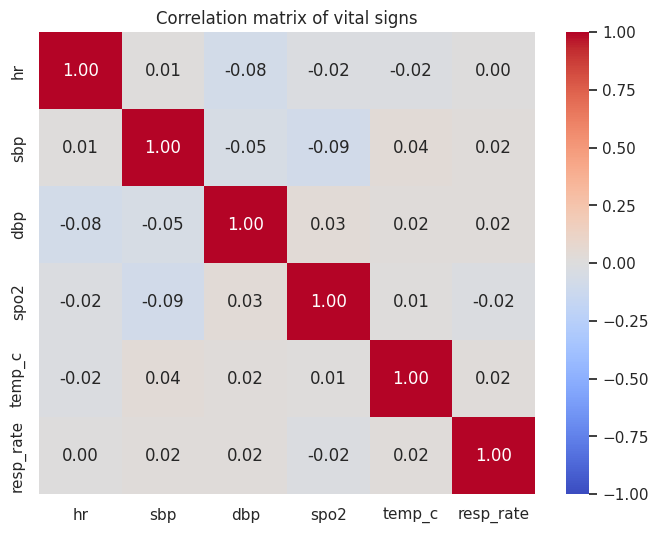

In [27]:
# Visual examination by scatterplot for everyvariable pair
sns.pairplot(
    df[['sbp','dbp','hr','resp_rate','spo2','temp_c','ward', 'age']],
    hue='ward'
)

plt.show()

plt.figure(figsize=(8,6))
corr = df[vital_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of vital signs')
plt.show()

### Step 9: Analysis

In [40]:
#flagged_rows = df[(df['temp_c'] > 39.0) | (df['spo2'] < 90)]

print("Total row flagged:", len(flagged_rows), "\n")

flagged_rows.head()

Total row flagged: 14 



,patient_id,age,sex,ward,timestamp,hr,sbp,dbp,spo2,temp_c,resp_rate,age_group
178,P1111,76,M,Med,2025-11-22 12:00:00,71.0,144.0,90.0,100.0,40.4,16,65+
347,P1067,62,F,Surg,2025-11-23 05:52:00,77.0,131.0,72.0,87.0,37.3,14,50-64
362,P1101,80,M,Med,2025-11-22 11:18:00,78.0,118.0,70.0,97.0,40.5,14,65+
693,P1101,80,M,Med,2025-11-20 05:19:00,56.0,122.0,80.0,96.0,40.9,15,65+
754,P1059,17,M,ICU,2025-11-20 05:48:00,106.0,124.0,98.0,89.0,36.8,17,<30


In [43]:
# Linear relationship between hr and tem_c
corr = df['hr'].corr(df['temp_c'], method='pearson')
print("Pearson correlation (hr vs temp_c):", corr)

# Interpret using thresholds
abs_corr = abs(corr)

if abs_corr < 0.3:
    strength = "weak"
elif abs_corr < 0.6:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if corr > 0 else "negative"

print(f"Interpretation: {strength} {direction} linear relationship between HR and temperature.")

Pearson correlation (hr vs temp_c): -0.017292984847349056
Interpretation: weak negative linear relationship between HR and temperature.


### Step 10: Reporting - Assemble Clinician-ready Summary

In [28]:
# Example Report: Summary by ward
ward_report = df.groupby('ward').agg(
    n_records=('patient_id', 'count'),
    hr_median=('hr', 'median'),
    hr_iqr=('hr', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    sbp_median=('sbp', 'median'),
    spo2_median=('spo2', 'median'),
    temp_mean=('temp_c', 'mean')
).reset_index()
ward_report

,ward,n_records,hr_median,hr_iqr,sbp_median,spo2_median,temp_mean
0,ICU,180,81.0,20.0,125.0,96.0,36.691667
1,Med,828,75.0,19.0,125.0,96.0,36.761957
2,Surg,432,79.0,20.0,118.0,96.0,36.694676


**Disclaimer:**
This project is completed as part of the course “Statistical Analysis and Data Modeling in Healthcare.” The core structure and foundational concepts are based on the course materials. However, additional content, modifications, and extensions have been included for the purpose of deeper learning and improved understanding. As a result, the final work may not exactly match the original course content.

### **End of Project**